In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [2]:
titanicDF = sb.load_dataset('titanic')
display(titanicDF)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Since this just an example for Logistic Regression, skipping the data imputation, correction, EDA etc. And also, we are considering few features, to directly build the model.

In [3]:
titanicDF.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [4]:
features=['pclass', 'sex', 'age','fare','embarked', 'adult_male' ,'alone']
target=['survived']

lgDF = titanicDF[features + target].copy()

In [5]:
lgDF

,pclass,sex,age,fare,embarked,adult_male,alone,survived
0,3,male,22.0,7.2500,S,True,False,0
1,1,female,38.0,71.2833,C,False,False,1
2,3,female,26.0,7.9250,S,False,True,1
3,1,female,35.0,53.1000,S,False,False,1
4,3,male,35.0,8.0500,S,True,True,0
...,...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,True,True,0
887,1,female,19.0,30.0000,S,False,True,1
888,3,female,NaN,23.4500,S,False,False,0
889,1,male,26.0,30.0000,C,True,True,1


In [6]:
lgDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      891 non-null    int64  
 1   sex         891 non-null    str    
 2   age         714 non-null    float64
 3   fare        891 non-null    float64
 4   embarked    889 non-null    str    
 5   adult_male  891 non-null    bool   
 6   alone       891 non-null    bool   
 7   survived    891 non-null    int64  
dtypes: bool(2), float64(2), int64(2), str(2)
memory usage: 43.6 KB


In [7]:
lgDF['age'] = lgDF['age'].fillna(lgDF['age'].median())
lgDF['embarked'] = lgDF['embarked'].fillna(lgDF['embarked'].mode()[0])


In [8]:
lgDF.isna().sum()

pclass        0
sex           0
age           0
fare          0
embarked      0
adult_male    0
alone         0
survived      0
dtype: int64

In [9]:
lgDF

,pclass,sex,age,fare,embarked,adult_male,alone,survived
0,3,male,22.0,7.2500,S,True,False,0
1,1,female,38.0,71.2833,C,False,False,1
2,3,female,26.0,7.9250,S,False,True,1
3,1,female,35.0,53.1000,S,False,False,1
4,3,male,35.0,8.0500,S,True,True,0
...,...,...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,True,True,0
887,1,female,19.0,30.0000,S,False,True,1
888,3,female,28.0,23.4500,S,False,False,0
889,1,male,26.0,30.0000,C,True,True,1


In [10]:
lgDF=pd.get_dummies(lgDF, columns=['sex','embarked'],drop_first=True)
lgDF

lgDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      891 non-null    int64  
 1   age         891 non-null    float64
 2   fare        891 non-null    float64
 3   adult_male  891 non-null    bool   
 4   alone       891 non-null    bool   
 5   survived    891 non-null    int64  
 6   sex_male    891 non-null    bool   
 7   embarked_Q  891 non-null    bool   
 8   embarked_S  891 non-null    bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 32.3 KB


In [11]:
x = lgDF.drop(target,axis=1)

In [12]:
y=lgDF['survived']

In [13]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [14]:
display(x)
display(y)

,pclass,age,fare,adult_male,alone,sex_male,embarked_Q,embarked_S
0,3,22.0,7.2500,True,False,True,False,True
1,1,38.0,71.2833,False,False,False,False,False
2,3,26.0,7.9250,False,True,False,False,True
3,1,35.0,53.1000,False,False,False,False,True
4,3,35.0,8.0500,True,True,True,False,True
...,...,...,...,...,...,...,...,...
886,2,27.0,13.0000,True,True,True,False,True
887,1,19.0,30.0000,False,True,False,False,True
888,3,28.0,23.4500,False,False,False,False,True
889,1,26.0,30.0000,True,True,True,False,False


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [15]:
# Stratify is the parameter that will tell the model to preserve the distribution of the outcome to be same as the training data. This is mostly useful incase of classification problem. Eg: in traing we have 90% of pass and 10% of fail entries, but in testing we have 70% of pass and 30% of fail. This change of distributon of data will affect the model prediction. So we have to tell the model, that distribute the test and train in the same proportion. 
# It is always y because, our model prediction is of target. So the proportion should be same for y especially.
xTrain,xTest,yTrain,yTest = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
print(f"xTrain.shape(): {xTrain.shape}, xTest.shape:{xTest.shape}, yTrain.shape():{yTrain.shape}, yTest.shape(): {yTest.shape}")

xTrain.shape(): (712, 8), xTest.shape:(179, 8), yTrain.shape():(712,), yTest.shape(): (179,)


In [17]:
sc = StandardScaler()
xTrainScaled = sc.fit_transform(xTrain)
xTestScaled = sc.transform(xTest)

In [18]:
xTrainScaled = pd.DataFrame(xTrainScaled,columns=xTrain.columns,index=xTrain.index)
xTestScaled = pd.DataFrame(xTestScaled,columns=xTrain.columns,index=xTest.index)


In [19]:
xTrainScaled

,pclass,age,fare,adult_male,alone,sex_male,embarked_Q,embarked_S
692,0.829568,-0.112078,0.513812,0.814587,0.800346,0.742427,-0.289333,0.611978
481,-0.370945,-0.112078,-0.662563,0.814587,0.800346,0.742427,-0.289333,0.611978
527,-1.571457,-0.112078,3.955399,0.814587,0.800346,0.742427,-0.289333,0.611978
855,0.829568,-0.879807,-0.467874,-1.227616,-1.249460,-1.346933,-0.289333,0.611978
801,-0.370945,0.118241,-0.115977,-1.227616,-1.249460,-1.346933,-0.289333,0.611978
...,...,...,...,...,...,...,...,...
359,0.829568,-0.112078,-0.498500,-1.227616,0.800346,-1.346933,3.456220,-1.634045
258,-1.571457,0.425333,10.005329,-1.227616,0.800346,-1.346933,-0.289333,-1.634045
736,0.829568,1.423382,0.053205,-1.227616,-1.249460,-1.346933,-0.289333,0.611978
462,-1.571457,1.346609,0.139097,0.814587,0.800346,0.742427,-0.289333,0.611978


In [20]:
xTestScaled

,pclass,age,fare,adult_male,alone,sex_male,embarked_Q,embarked_S
565,0.829568,-0.419170,-0.159704,0.814587,-1.249460,0.742427,-0.289333,0.611978
160,0.829568,1.116290,-0.327324,0.814587,-1.249460,0.742427,-0.289333,0.611978
553,0.829568,-0.572716,-0.512122,0.814587,0.800346,0.742427,-0.289333,-1.634045
860,0.829568,0.885971,-0.368795,0.814587,-1.249460,0.742427,-0.289333,0.611978
241,0.829568,-0.112078,-0.339817,-1.227616,-1.249460,-1.346933,3.456220,-1.634045
...,...,...,...,...,...,...,...,...
880,-0.370945,-0.342397,-0.121182,-1.227616,-1.249460,-1.346933,-0.289333,0.611978
91,0.829568,-0.726262,-0.499020,0.814587,0.800346,0.742427,-0.289333,0.611978
883,-0.370945,-0.112078,-0.443929,0.814587,0.800346,0.742427,-0.289333,0.611978
473,-0.370945,-0.495943,-0.375388,-1.227616,0.800346,-1.346933,-0.289333,-1.634045


In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(xTrainScaled,yTrain)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
yTrain

692    1
481    0
527    0
855    1
801    1
      ..
359    1
258    1
736    0
462    0
507    1
Name: survived, Length: 712, dtype: int64

In [23]:
model.coef_

array([[-0.98297191, -0.26814632,  0.02221987, -0.96151407,  0.15815743,
        -0.45527123,  0.03779235, -0.23481794]])

In [24]:
model.intercept_

array([-0.69945794])

### By default, the treshhold is 0.5. Now we can find the probabilty of each class( 0/1, pass/fail) even before prediction. That is via predict_proba()

In [25]:
model.predict_proba(xTrainScaled)

array([[0.93231015, 0.06768985],
       [0.81287465, 0.18712535],
       [0.54639558, 0.45360442],
       ...,
       [0.61160194, 0.38839806],
       [0.65972228, 0.34027772],
       [0.56867429, 0.43132571]], shape=(712, 2))

### The above array of numbers, 2 values fro each row, if the probability of 0 and 1, respectively.

In [26]:
yTrainPredict = model.predict(xTrainScaled)

In [27]:
yTrainPredict
#0 is -ve case, 1 is +ve case.

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,

In [28]:
type(yTrain)

pandas.Series

In [29]:
type(yTrainPredict)

numpy.ndarray

In [30]:
PredictioncheckDF = pd.DataFrame(
    {
        "y-Actual": yTrain,
        "y-Predicted": yTrainPredict
    }
)

In [31]:
PredictioncheckDF

,y-Actual,y-Predicted
692,1,0
481,0,0
527,0,0
855,1,1
801,1,1
...,...,...
359,1,1
258,1,1
736,0,0
462,0,0


## When we apply treshhold, or by default, if treshhold is applied, then the treshhold value will be compared with the class 1(2nd element of the array of predict proba)

In [32]:
treshhold = 0.2
predictions=[]

for i in model.predict_proba(xTrainScaled):
    if(i[1] > treshhold):
        predictions.append(1)
    else:
        predictions.append(0)   

print(predictions)        


[0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 

### How correct is my model

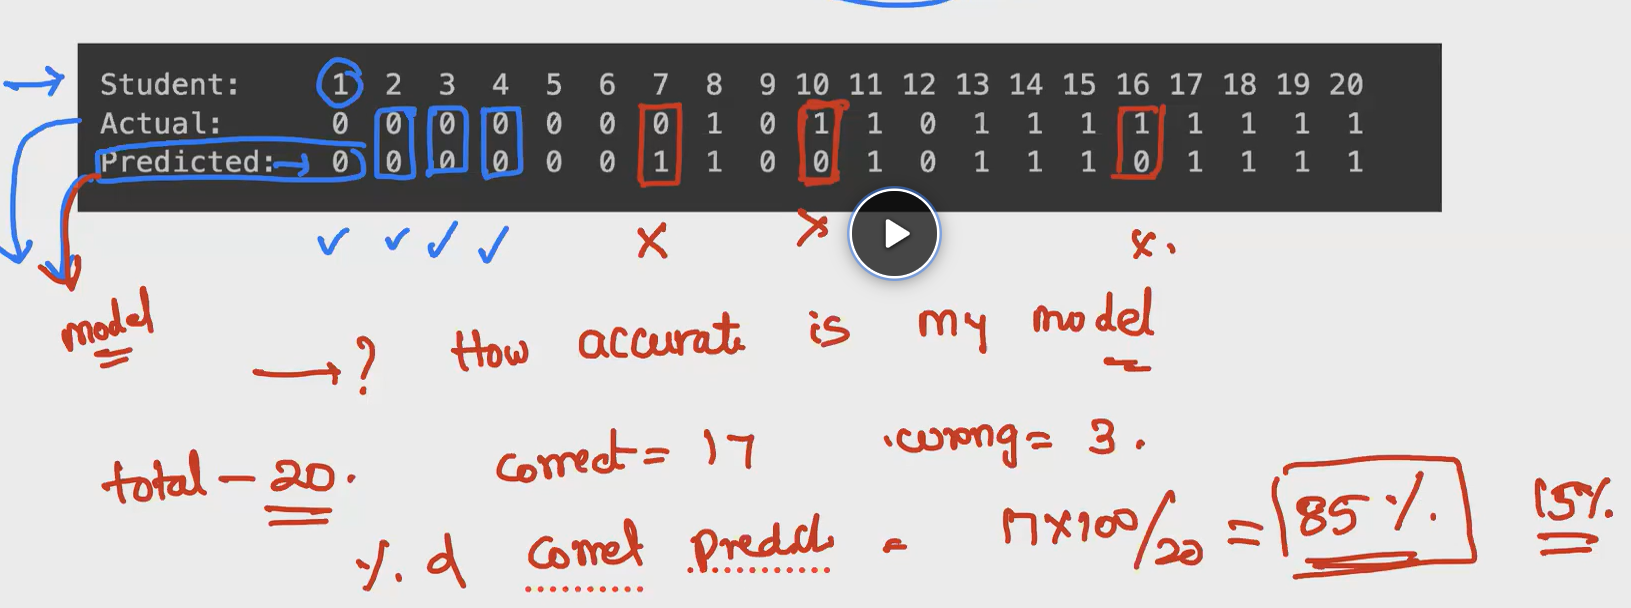

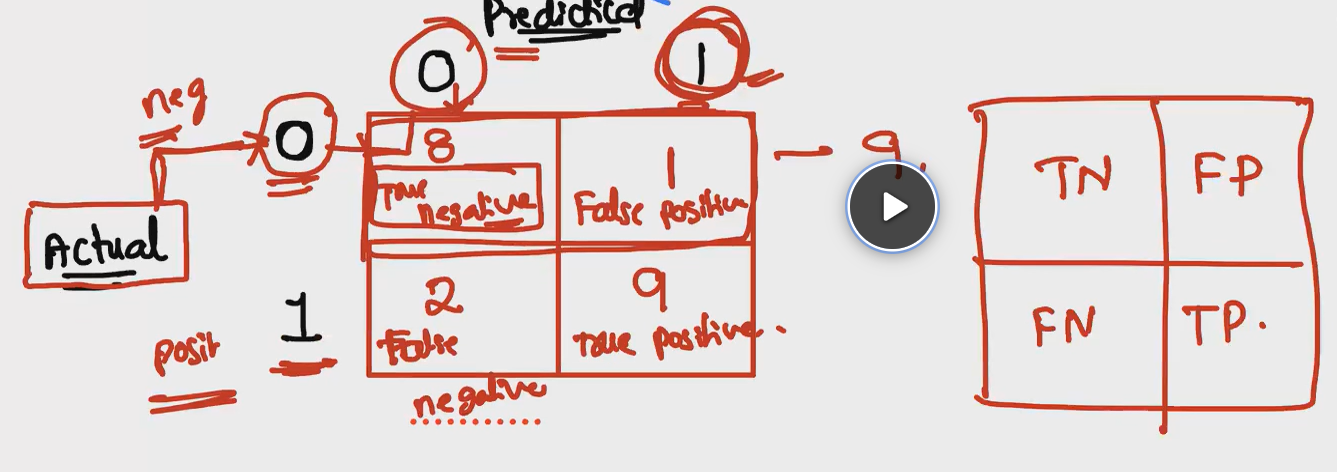

- **True Positive(TP)** : How many 1's are predicted correctly by the model, when the actual is 1.
- **True Negative(TN)** : How many 0's are predicted correctly by the model, when the actual is 0.
- **False Positive(FP)** : How many 1's are predicted wrongly by the model, when the actual is 0.
- **False Negative(FN)** : How many 0's are predicted wrongly by the model, when the actual is 1.

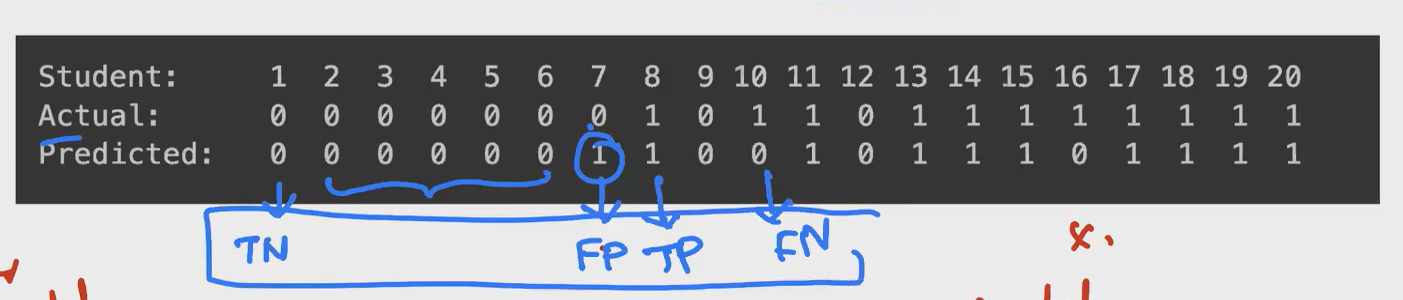

#### Confusion Matrix - It is the same as the above table, but with the no.of TN,TP.FN,FP.
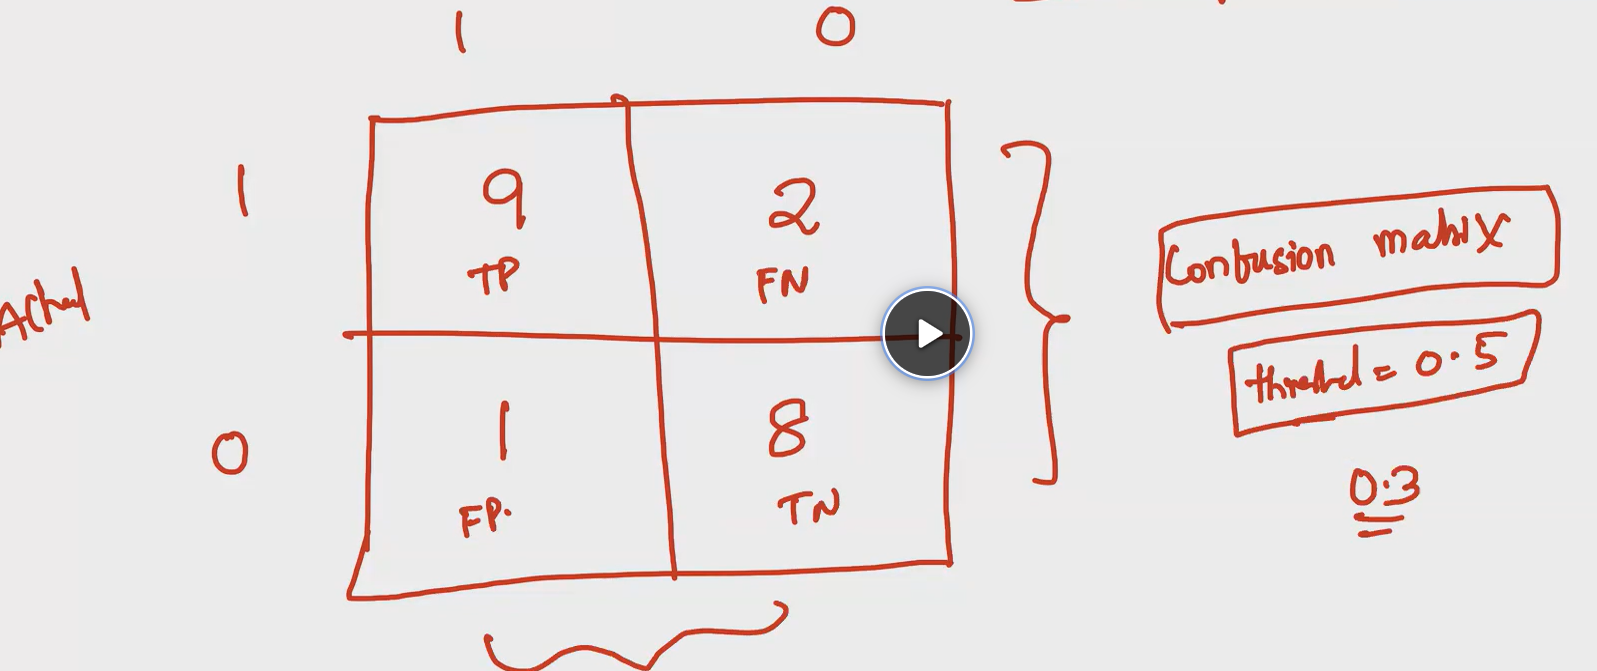

- If we change the treshhold value, then the values in the confusion matrix will also change.

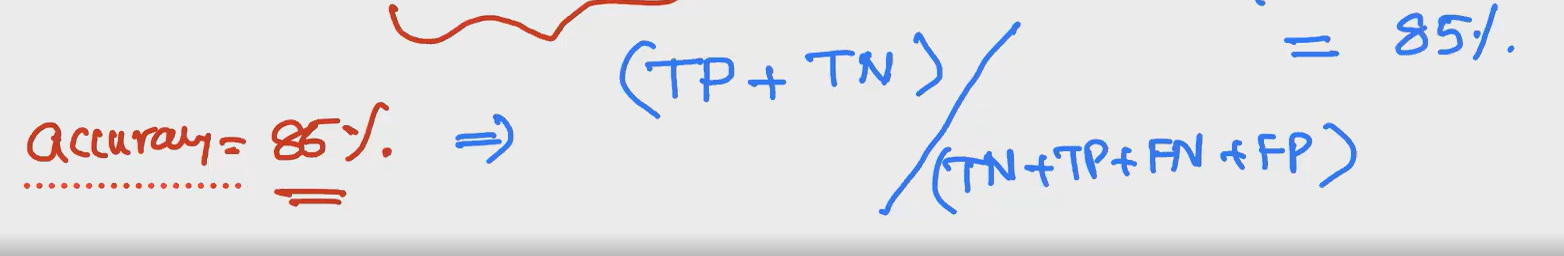
- The 85 % is the sample just to relate with image 1


### Can we entirely trust Accuracy to grade our model?????
## NO!!!! Why????

For eg: We have a fraud transacrion dataset, where 9900 are legit and 100 are fraud transactiuons. Now, w/o a ML model, when we return "Legit" as result for all entries, then my accuracy will become 99% according to the confusion matrix. But even w/o or with ML model what if the accuracy is 99%, but still the model is not exposed to fraud transactions??  **So we cannot blindly trust accuracy**
Moreover, my dataset is biased, more inclined with legitimate transactions. So, ***When we have a biased dataset, Accuracy should not be the metric to grade our model.***

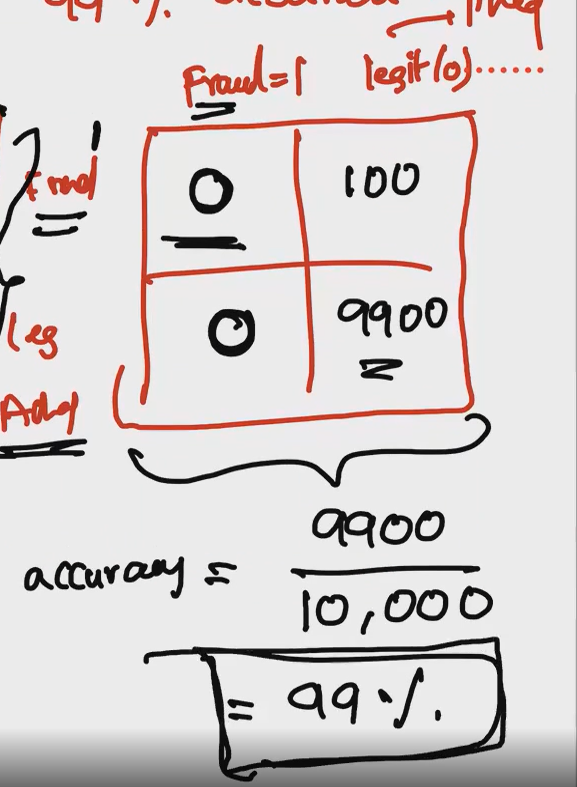

### Then how will I grade my model when my dataset is biased???? 
***For that we have Precision, recall and F1 Score***


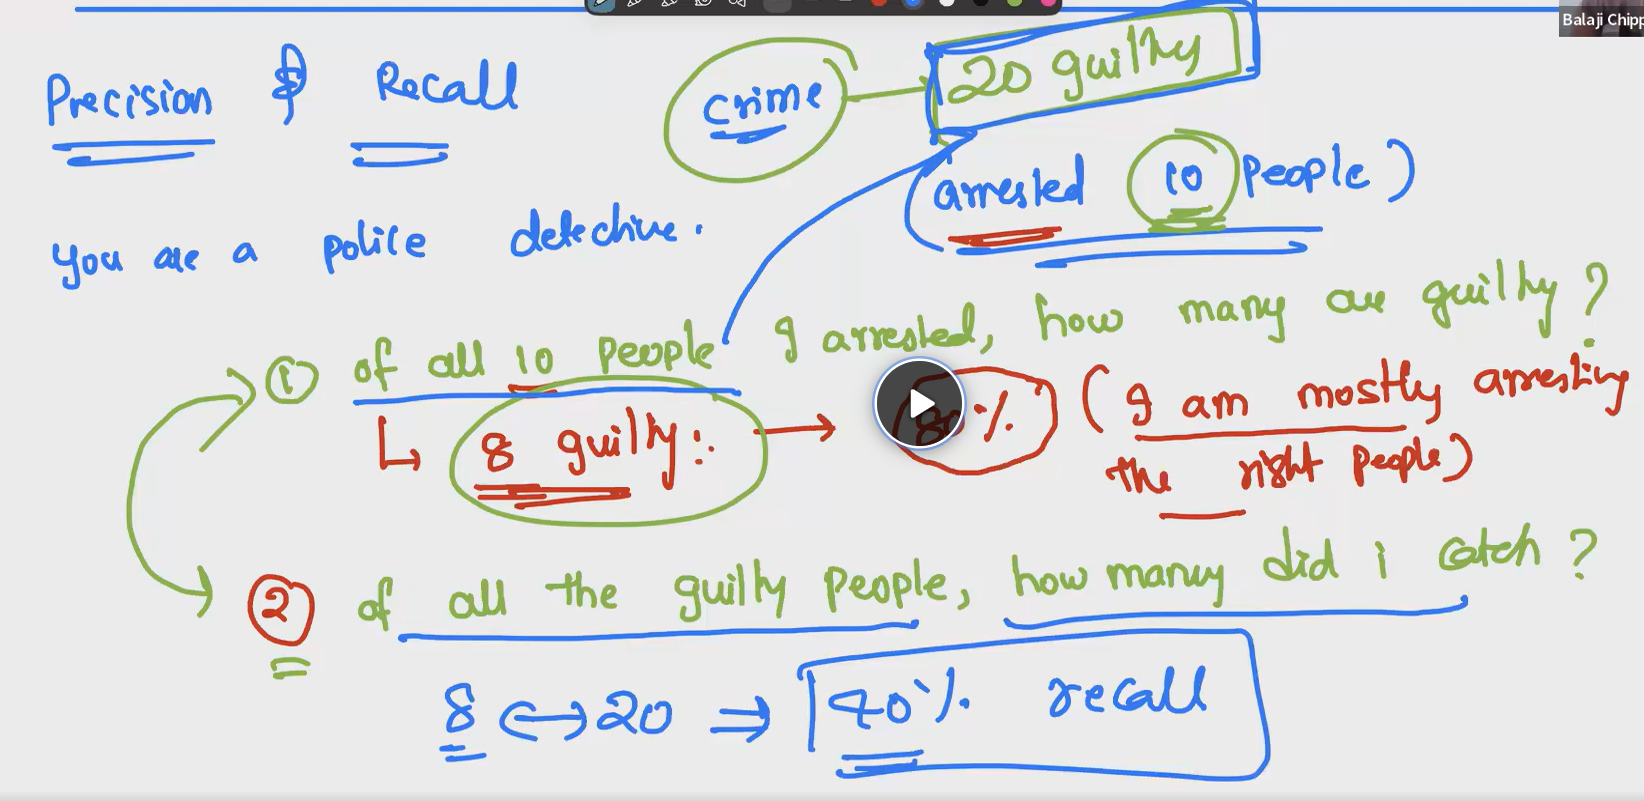
In the above police detectivve - crime example:
- No.of people I arrested: 10(8 guilty, 2 not guilty)
- No.of people involved in that crime, actually: 20.
- ***Q1: Out of the arrested people, how many are actually involved in crime? Ans: 8(80% out of 10)*** - **Precision**
- ***Q1: Out of the total people involved in crime, how many criminals are arrested? Ans: 8(40% out of 20)*** - **Recall**

***Here +ve means crime and criminals***

### PRECISION AND RECALL - IN TECH TERMS:
1. **Precision** - Of all the instances I predicted as positive, how many were actually positive?
2. **Recall** - Of all the actual positive instances, how many did I find?

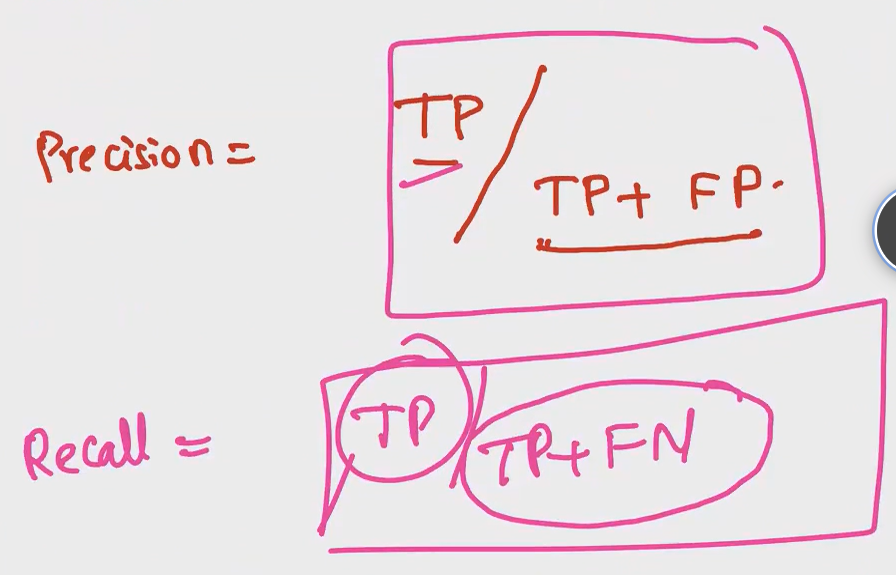

### For the above Dataset, which is balanced:
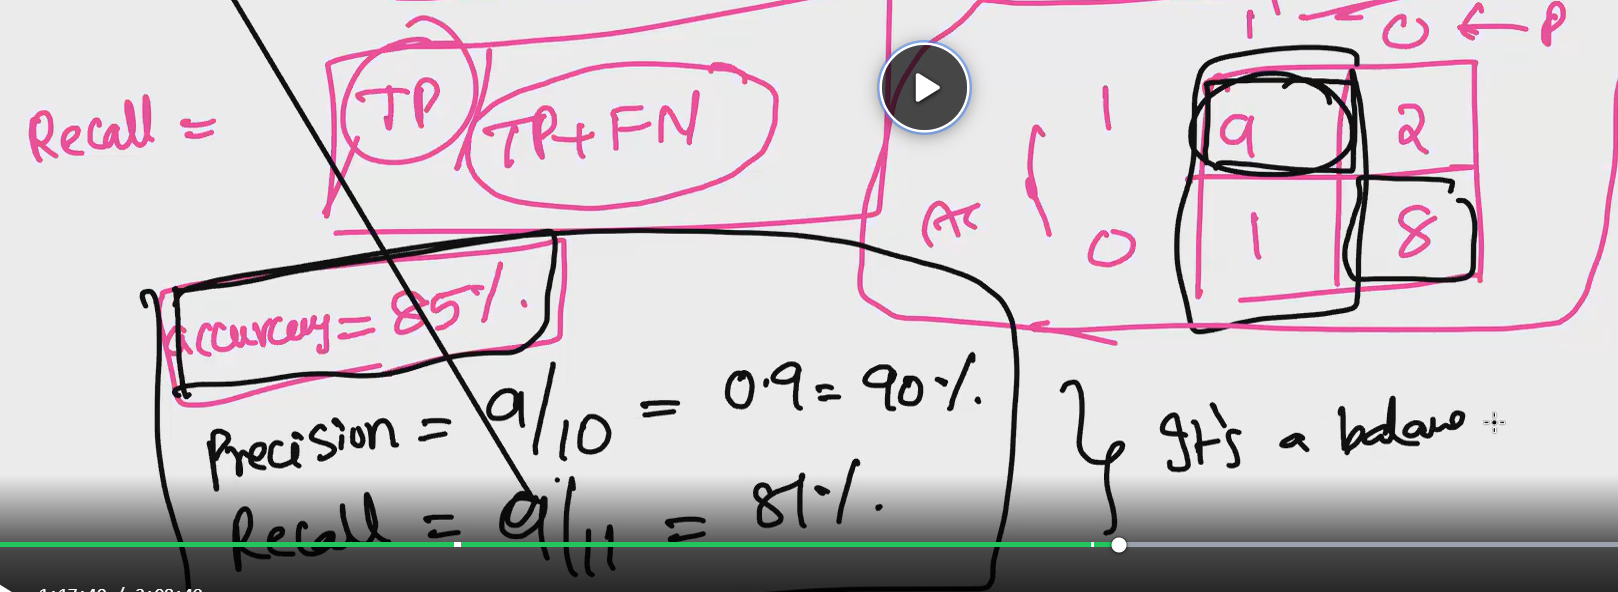

### For the fraud transaction dataset, which is imbalanced:
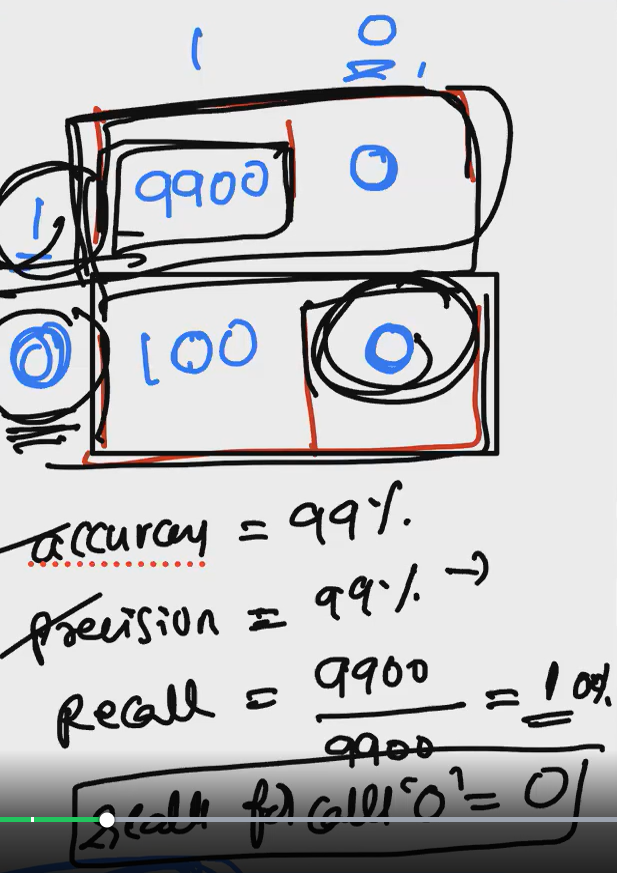

- Here, we also need to calculate the recall of 0, since we know that the data set is imbalaced, biased over class 1.
- When the data is not balanced, then we need to look into the precision and recalss of both classes, to decide the correctness of the model.
- Mostly, getting both recall and precision high, is almost not possible. It is rare.
- Which is important: either precision or recall, depends on the usecase.
- Eg1: Recall is important, when the usecase is cancer or any disease detection.
- Eg2: Precision is important when reporting emails as spam/not spam.

### F1 SCORE
***The F1 Score is used when you want a single metric that balances both Precision and Recall.***
- F1 score reflect the lowest metric more, meaning it will be low even any one of precision and recall, is low. It penalises low values heavily.

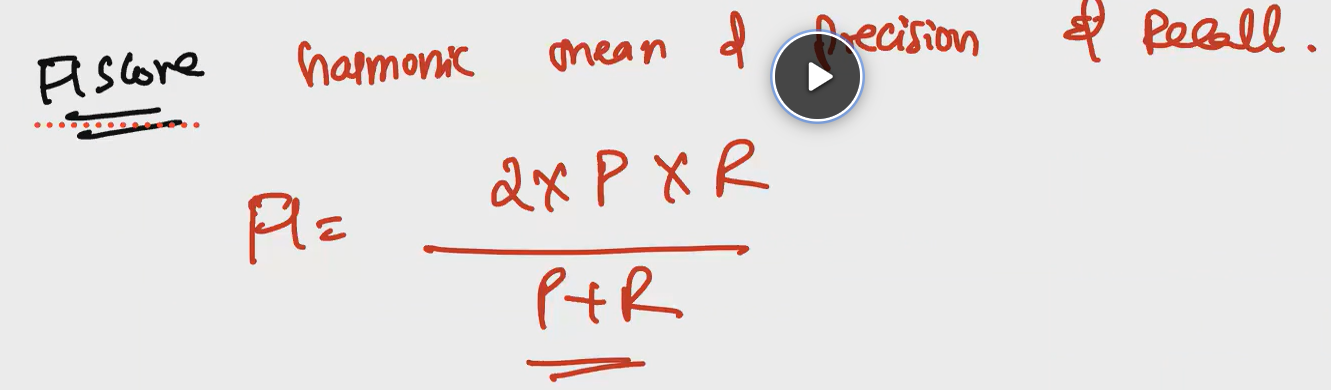

# When to Use Precision, Recall, and F1 Score

| Metric | Focuses On | Use When | Example Use Cases |
|----------|------------|------------|------------------|
| **Precision** | Minimizing False Positives (FP) | A false positive is more costly than a false negative. You want predictions labeled as positive to be highly trustworthy. | Spam detection, Email filtering, Fraud alerts requiring manual review |
| **Recall** | Minimizing False Negatives (FN) | Missing a positive case is more costly than incorrectly flagging a negative case. | Cancer detection, Disease screening, Fraud detection, Security threat detection |
| **F1 Score** | Balance between Precision and Recall | Both false positives and false negatives are important, and you need a single metric to evaluate the model. | Search engines, Recommendation systems, General classification problems with imbalanced data |

## Quick Decision Guide

| Scenario | Metric to Prioritize | Reason |
|-----------|---------------------|---------|
| Sending important emails to spam folder | Precision | Legitimate emails should not be marked as spam. |
| Detecting cancer patients | Recall | Missing a patient can have serious consequences. |
| Detecting fraudulent transactions | Recall | Better to investigate extra transactions than miss actual fraud. |
| Search engine results | Precision | Users want relevant results at the top. |
| Security intrusion detection | Recall | Missing an attack is worse than investigating false alarms. |
| General model comparison with imbalanced data | F1 Score | Provides a balanced view of Precision and Recall. |

## Rule of Thumb

- **Precision** → "When I predict Positive, how often am I correct?"
- **Recall** → "Of all actual Positives, how many did I find?"
- **F1 Score** → "How good am I at both Precision and Recall together?"

## Formulae

Precision:

\[
Precision = {TP}/{TP + FP}
\]

Recall:

\[
Recall = {TP}/{TP + FN}
\]

F1 Score:

\[
F1 = {2 * Precision * Recall}/{Precision + Recall}
\]

### Building confusion matrix,precision, recall score, f1 score using Python sklearn lib.

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,precision_score,recall_score,f1_score

In [34]:
cm = confusion_matrix(yTrain,yTrainPredict)
cm

array([[378,  61],
       [ 70, 203]])

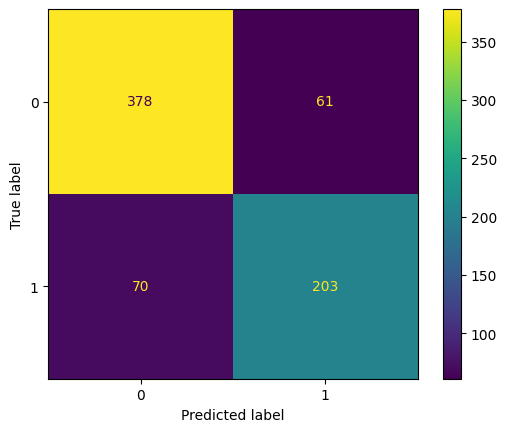

In [38]:
from matplotlib import pyplot as plt

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()


In [49]:
precisionScore = precision_score(yTrain,yTrainPredict)
recallScore = recall_score(yTrain,yTrainPredict)
f1Score = f1_score(yTrain,yTrainPredict)
print(f"Precision Score: {precisionScore:.2%}, Recall Score: {recallScore:.2%}, F1 Score: {f1Score:.2%}")

Precision Score: 76.89%, Recall Score: 74.36%, F1 Score: 75.61%


### Building confusion matrix,precision, recall score, f1 score using Python vanilla code.

In [50]:
tp=0
tn=0
fp=0
fn=0

for i,j in zip(yTrain, yTrainPredict):
    if(i == 1 and j == 1):
        tp += 1
    elif(i == 0 and j == 0):
        tn += 1 
    elif(i == 1 and j == 0):
        fn += 1  
    elif(i == 0 and j == 1):
        fp += 1 
print(f"True Positive: {tp}, True Negative: {tn}, False Positive: {fp}, False Negative: {fn}")         
precisionScore = tp/(tp+fp)
recallScore = tp/(tp+fn)     
f1Score=(2*recallScore*precisionScore)/(recallScore+precisionScore)
print(f"Precision Score: {precisionScore:.2%}, Recall Score: {recallScore:.2%}, F1 Score: {f1Score:.2%}")   

True Positive: 203, True Negative: 378, False Positive: 61, False Negative: 70
Precision Score: 76.89%, Recall Score: 74.36%, F1 Score: 75.61%
